## Setup Instructions

This notebook is configured for local execution from the XAllergen2.0 repo only.

1. Open the notebook from inside the local `XAllergen2.0` project folder.
2. Use a Python environment with the dependencies in `pyproject.toml` installed.
3. Confirm these local files exist before running all cells:
   - `data/positives_splitB.csv`
   - `model/DeepPlantAllergy/best_full_model_epoch43_20260421_101130_seed_42.pt`
   - `deep_plant_allergy_utils.py`
4. MPS is used when available on macOS, otherwise CPU.
5. Results are saved to the local `results/` directory.


# 04 — Probing Metrics: DeepPlantAllergy

Evaluates the mechanistic faithfulness of the `EnhancedProteinModelFull`
DeepPlantAllergy classifier by comparing residue-level attribution maps
against experimentally validated IEDB epitope annotations from
`positives_splitB.csv`.

This local-only notebook mirrors `04_probing_metrics.ipynb`, but loads the
trained checkpoint from `model/DeepPlantAllergy` and uses
`deep_plant_allergy_utils.py` for architecture, checkpoint loading, ESM-2
embedding, attention aggregation, and integrated gradients.


In [1]:
import sys
from pathlib import Path

# Allow imports from the src-layout package without a root-level shim.
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    _src_dir = _candidate / "src"
    if (_src_dir / "xallergen").exists() and str(_src_dir) not in sys.path:
        sys.path.insert(0, str(_src_dir))
        break

from xallergen.deep_plant_allergy_utils import (
    ESM_MODEL_NAME,
    HF_MODEL_NAME,
    HIDDEN_DIM,
    IG_STEPS,
    MAX_SEQ_LEN,
    RANDOM_STATE,
    build_embedding_model,
    build_tokenizer,
    compute_attention_weights,
    compute_integrated_gradients,
    configure_matplotlib_cache,
    detect_device,
    find_project_root,
    load_deep_plant_allergy_checkpoint,
    mean_metric_dicts,
    print_runtime_context,
    seed_everything,
)

configure_matplotlib_cache(Path.cwd())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score
from statsmodels.nonparametric.smoothers_lowess import lowess
from tqdm.auto import tqdm

N_RANDOM_DRAWS = 100

PROJECT_ROOT = find_project_root(Path.cwd())
DEVICE = detect_device()
print_runtime_context(DEVICE, PROJECT_ROOT)

DATA_DIR    = PROJECT_ROOT / "data"
MODEL_DIR   = PROJECT_ROOT / "model" / "DeepPlantAllergy"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

POSITIVES_CSV     = DATA_DIR   / "positives_splitB.csv"
CHECKPOINT_PATH   = MODEL_DIR  / "best_full_model_epoch43_20260421_101130_seed_42.pt"
SUMMARY_CSV       = RESULTS_DIR / "probing_summary_deep_plant_allergy.csv"
VIOLINS_PNG       = RESULTS_DIR / "probing_violins_deep_plant_allergy.png"
AUROC_DENSITY_PNG = RESULTS_DIR / "probing_auroc_vs_density_deep_plant_allergy.png"
AUPRC_DENSITY_PNG = RESULTS_DIR / "probing_auprc_vs_density_deep_plant_allergy.png"

seed_everything(RANDOM_STATE)


Matplotlib is building the font cache; this may take a moment.


RUN_TARGET: local
Device: mps
Project root: /Users/anxiongsong/XAllergen2.0
GPU configuration:
  backend: Apple Metal Performance Shaders (MPS)
  built with MPS: True
  MPS available: True


In [2]:
missing = [path for path in [POSITIVES_CSV, CHECKPOINT_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Required local files not found:\n" + "\n".join(f"  {path}" for path in missing)
    )
print("All required local files verified.")


All required local files verified.


## Data — Load and Parse Epitope Labels

In [3]:
raw_df = pd.read_csv(POSITIVES_CSV)
raw_df["accession"] = raw_df["accession"].astype(str)
raw_df["sequence"]  = raw_df["sequence"].astype(str).str.strip().str.upper()


def parse_epitope_label(
    sequence: str, epitope_start: str, epitope_end: str
) -> np.ndarray:
    """Build a binary per-residue label vector from semicolon-separated
    interval boundaries (1-indexed, inclusive).

    epitope_start = "14;45"  and  epitope_end = "27;89"  encodes intervals
    [14, 27] and [45, 89].
    """
    starts = [int(s) for s in str(epitope_start).split(";")]
    ends   = [int(e) for e in str(epitope_end).split(";")]
    label  = np.zeros(len(sequence), dtype=np.int32)
    for s, e in zip(starts, ends):
        label[s - 1 : e] = 1  # 1-indexed inclusive → 0-indexed Python slice
    return label


records = []
degenerate_rows = []

for _, row in raw_df.iterrows():
    label_vec  = parse_epitope_label(row["sequence"], row["epitope_start"], row["epitope_end"])
    n_epitope  = int(label_vec.sum())
    seq_len    = len(row["sequence"])
    
    if n_epitope == 0:
        degenerate_rows.append({"accession": row["accession"], "reason": "no_epitope_residues", "seq_len": seq_len, "n_epitope": n_epitope})
        continue
    if n_epitope == seq_len:
        degenerate_rows.append({"accession": row["accession"], "reason": "all_epitope_residues", "seq_len": seq_len, "n_epitope": n_epitope})
        continue

    records.append({
        "accession":          row["accession"],
        "sequence":           row["sequence"],
        "epitope_label":      label_vec,
        "seq_len":            seq_len,
        "n_epitope_residues": n_epitope,
        "epitope_density":    n_epitope / seq_len,
    })

if degenerate_rows:
    deg_df = pd.DataFrame(degenerate_rows)
    print(f"Filtered {len(deg_df)} degenerate proteins (uninformative for residue-level ranking):")
    print(deg_df.to_string(index=False))
else:
    print("No degenerate proteins found.")

eval_df = pd.DataFrame(records).reset_index(drop=True)
print(f"Proteins after filtering degenerate cases: {len(eval_df)}")

No degenerate proteins found.
Proteins after filtering degenerate cases: 60


## Model — DeepPlantAllergy EnhancedProteinModelFull


In [6]:
tokenizer = build_tokenizer(HF_MODEL_NAME)
embedding_model = build_embedding_model(HF_MODEL_NAME, DEVICE)


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: /Users/anxiongsong/.cache/huggingface/hub/models--facebook--esm2_t6_8M_UR50D/snapshots/c731040fcd8d73dceaa04b0a8e6329b345b0f5df
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
model, checkpoint = load_deep_plant_allergy_checkpoint(
    CHECKPOINT_PATH,
    DEVICE,
)
arch_hp = checkpoint["architecture_hyperparameters"]

print(f"Loaded checkpoint:  {CHECKPOINT_PATH}")
print(f"ESM model:          {checkpoint.get('esm_model_name', ESM_MODEL_NAME)}")
print(
    "Architecture: "
    f"embedding_dim={arch_hp['embedding_dim']}, "
    f"hidden_dim={arch_hp['hidden_dim']}, "
    f"lstm_layers={arch_hp['num_lstm_layers']}, "
    f"attention_heads={arch_hp['num_attention_heads']}, "
    f"fc_layers={arch_hp['num_fc_layers']}"
)


Loaded checkpoint:  /Users/anxiongsong/XAllergen2.0/model/DeepPlantAllergy/best_full_model_epoch43_20260421_101130_seed_42.pt
ESM model:          esm2_t6_8M_UR50D
Architecture: embedding_dim=320, hidden_dim=128, lstm_layers=3, attention_heads=8, fc_layers=3


## Attribution Methods

In [8]:
def _precision_at_k(y_true: np.ndarray, scores: np.ndarray) -> float:
    k = int(y_true.sum())
    if k == 0:
        return float("nan")
    top_k = np.argsort(scores)[::-1][:k]
    return float(y_true[top_k].sum() / k)


def compute_metrics(y_true: np.ndarray, scores: np.ndarray) -> dict:
    if len(np.unique(y_true)) < 2:
        auroc = float("nan")
    else:
        auroc = float(roc_auc_score(y_true, scores))
    return {
        "auroc": auroc,
        "auprc": float(average_precision_score(y_true, scores)),
        "precision_at_k": _precision_at_k(y_true, scores),
    }


## Evaluation Loop

Processes proteins one at a time. ESM-2 residue embeddings are generated on the fly,
then passed through the DeepPlantAllergy classifier. Sequences longer than 1000
ESM residue tokens are skipped to match the training maximum length.


In [9]:
print(eval_df.shape)
print(eval_df.columns.tolist())
print(eval_df.head())

(60, 6)
['accession', 'sequence', 'epitope_label', 'seq_len', 'n_epitope_residues', 'epitope_density']
    accession                                           sequence  \
0  A0A834K244  MEISGLVYLIIIVTIIDLPYGKANNYCKIKCLKGGVHTACKYGSLK...   
1      I1KMV0  MGVFTFEDEINSPVAPATLYKALVTDADNVIPKALDSFKSVENVEG...   
2  A0ABQ9K8B4  MGRVMNIFIVVLLCLTGVAIAEQCGRQAGGKLCPNNLCCSQWGWCG...   
3      Q28133  MKAVFLTLLFGLVCTAQETPAEIDPSKIPGEWRIIYAAADNKDKIV...   
4      P79017  MAALLRLAVLLPLAAPLVATLPTSPVPIAARATPHEPVFFSWDAGA...   

                                       epitope_label  seq_len  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      251   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      165   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      208   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      172   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      310   

   n_epitope_residues  epitope_density  
0                 138         0.549801  
1              

In [12]:
rng = np.random.default_rng(RANDOM_STATE)

results_rows = []
n_skipped = 0

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating proteins"):
    sequence = row["sequence"]
    epitope_labels = row["epitope_label"]
    accession = row["accession"]
    seq_len = row["seq_len"]

    tok_len = tokenizer(sequence, add_special_tokens=False, return_tensors="pt")["input_ids"].shape[1]
    if tok_len > MAX_SEQ_LEN:
        n_skipped += 1
        continue

    base = {
        "accession": accession,
        "seq_len": seq_len,
        "epitope_density": row["epitope_density"],
        "n_epitope_residues": row["n_epitope_residues"],
    }

    attn_scores = None
    try:
        attn_scores = compute_attention_weights(model, embedding_model, tokenizer, sequence, DEVICE)
        results_rows.append(
            {**base, "method": "attention_weights", **compute_metrics(epitope_labels, attn_scores)}
        )
    except Exception as exc:
        print(f"[attention] {accession}: {exc}")

    try:
        ig_scores = compute_integrated_gradients(
            model,
            embedding_model,
            tokenizer,
            sequence,
            DEVICE,
            steps=IG_STEPS,
            normalize=False,
        )
        results_rows.append(
            {**base, "method": "integrated_gradients", **compute_metrics(epitope_labels, ig_scores)}
        )
    except Exception as exc:
        print(f"[IG] {accession}: {exc}")

    rand_metrics = [
        compute_metrics(epitope_labels, rng.uniform(0.0, 1.0, size=seq_len))
        for _ in range(N_RANDOM_DRAWS)
    ]
    results_rows.append({
        **base,
        "method": "random_mean",
        **mean_metric_dicts(rand_metrics),
    })

    if attn_scores is not None:
        try:
            shuffled_metrics = [
                compute_metrics(rng.permutation(epitope_labels), attn_scores)
                for _ in range(N_RANDOM_DRAWS)
            ]
            results_rows.append({
                **base,
                "method": "shuffled_mean",
                **mean_metric_dicts(shuffled_metrics),
            })
        except Exception as exc:
            print(f"[shuffled] {accession}: {exc}")

print(f"\nSkipped {n_skipped} proteins exceeding MAX_SEQ_LEN={MAX_SEQ_LEN}")
results_df = pd.DataFrame(results_rows)
print(f"Total result rows: {len(results_df)}")
print(results_df["method"].value_counts().to_string())


Evaluating proteins:   0%|          | 0/60 [00:00<?, ?it/s]


Skipped 0 proteins exceeding MAX_SEQ_LEN=1000
Total result rows: 240
method
attention_weights       60
integrated_gradients    60
random_mean             60
shuffled_mean           60


## Figures

/var/folders/2g/g1_kd2rx0_72n_lfp7xfsd_00000gn/T/ipykernel_29899/1608909809.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/2g/g1_kd2rx0_72n_lfp7xfsd_00000gn/T/ipykernel_29899/1608909809.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/2g/g1_kd2rx0_72n_lfp7xfsd_00000gn/T/ipykernel_29899/1608909809.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
/var/folders/2g/g1_kd2rx0_72n_lfp7xfsd_00000gn/T/ipykernel_29899/1608909809.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is d

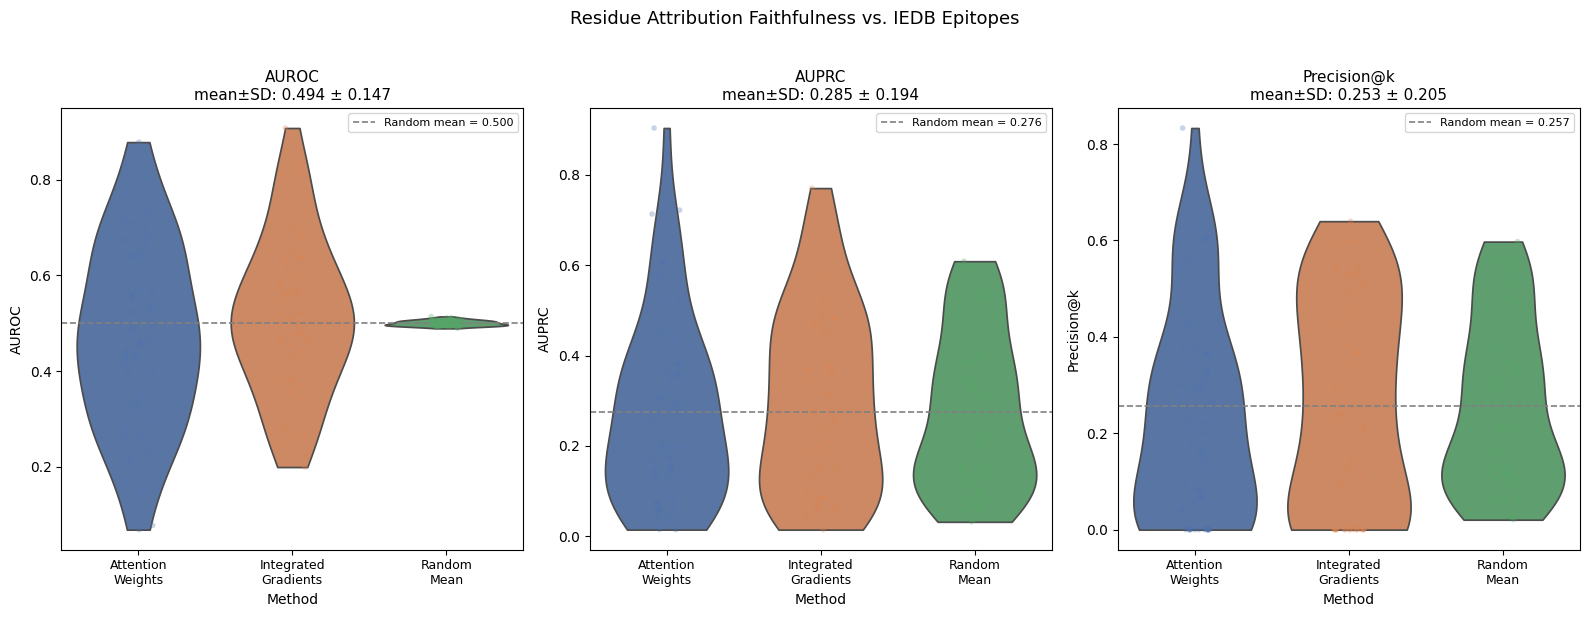

Saved: /Users/anxiongsong/XAllergen2.0/results/probing_violins_deep_plant_allergy.png


In [13]:
PALETTE = {
    "attention_weights":    "#4C72B0",
    "integrated_gradients": "#DD8452",
    "random_mean":          "#55A868",
}
METHOD_XLABELS = {
    "attention_weights":    "Attention\nWeights",
    "integrated_gradients": "Integrated\nGradients",
    "random_mean":          "Random\nMean",
}

violin_order   = ["attention_weights", "integrated_gradients", "random_mean"]
violin_df      = results_df[results_df["method"].isin(violin_order)].copy()
metrics_config = [
    ("auroc",          "AUROC"),
    ("auprc",          "AUPRC"),
    ("precision_at_k", "Precision@k"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (col, label) in zip(axes, metrics_config):
    plot_data = violin_df.dropna(subset=[col]).copy()

    sns.violinplot(
        data=plot_data, x="method", y=col,
        palette=PALETTE, inner=None, cut=0, order=violin_order, ax=ax,
    )
    sns.stripplot(
        data=plot_data, x="method", y=col,
        palette=PALETTE, alpha=0.3, size=4, jitter=True, order=violin_order, ax=ax,
    )

    rand_mean = plot_data.loc[plot_data["method"] == "random_mean", col].mean()
    ax.axhline(
        rand_mean, color="gray", linestyle="--", linewidth=1.2,
        label=f"Random mean = {rand_mean:.3f}",
    )

    overall_mean = plot_data[col].mean()
    overall_sd   = plot_data[col].std()
    ax.set_title(f"{label}\nmean\u00b1SD: {overall_mean:.3f} \u00b1 {overall_sd:.3f}", fontsize=11)
    ax.set_xlabel("Method")
    ax.set_ylabel(label)
    ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Residue Attribution Faithfulness vs. IEDB Epitopes", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(VIOLINS_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {VIOLINS_PNG}")

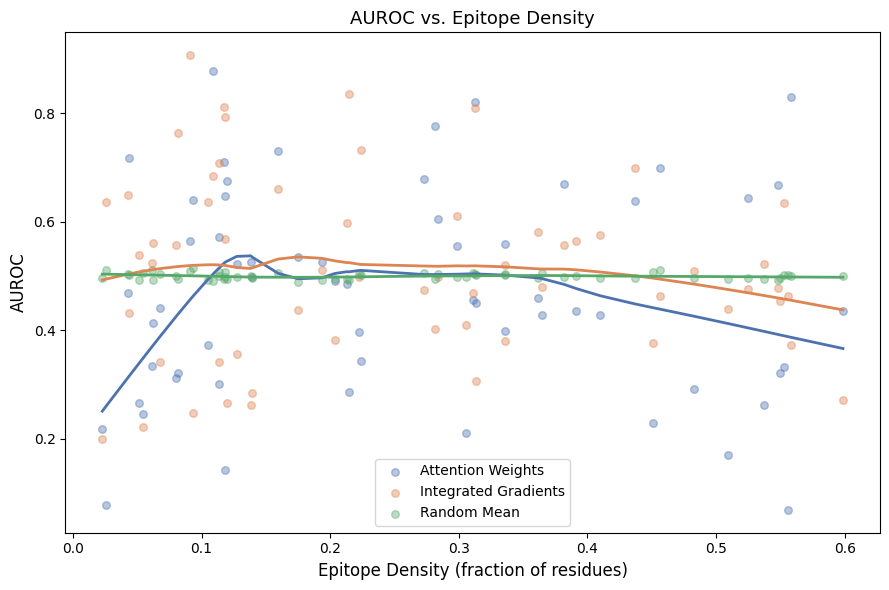

Saved: /Users/anxiongsong/XAllergen2.0/results/probing_auroc_vs_density_deep_plant_allergy.png


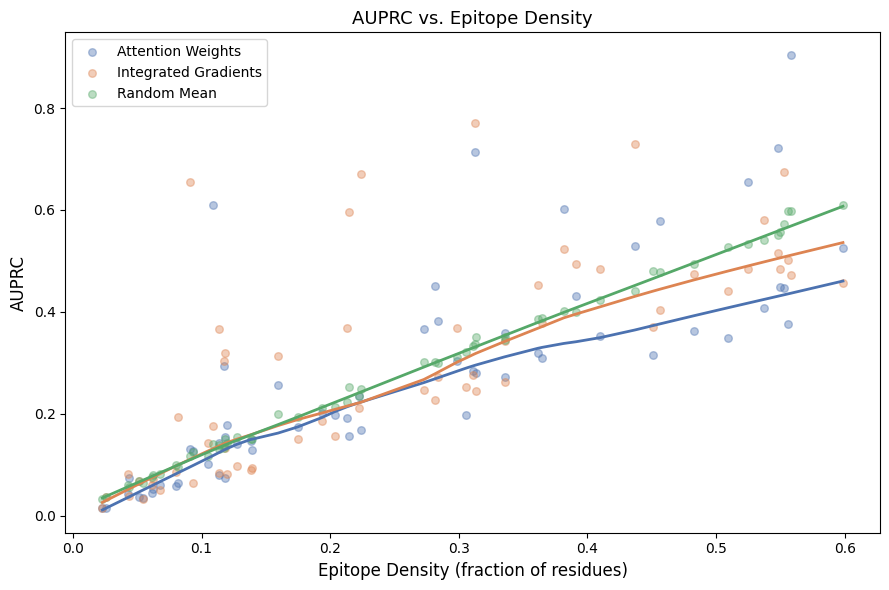

Saved: /Users/anxiongsong/XAllergen2.0/results/probing_auprc_vs_density_deep_plant_allergy.png


In [14]:
scatter_methods = ["attention_weights", "integrated_gradients", "random_mean"]
scatter_df      = results_df[results_df["method"].isin(scatter_methods)].copy()

for metric_col, metric_label, out_path in [
    ("auroc", "AUROC", AUROC_DENSITY_PNG),
    ("auprc", "AUPRC", AUPRC_DENSITY_PNG),
]:
    fig, ax = plt.subplots(figsize=(9, 6))

    for method in scatter_methods:
        mdf   = scatter_df[scatter_df["method"] == method].dropna(
            subset=[metric_col, "epitope_density"]
        )
        color = PALETTE[method]
        ax.scatter(
            mdf["epitope_density"], mdf[metric_col],
            color=color, alpha=0.4, s=30,
            label=method.replace("_", " ").title(),
        )
        if len(mdf) >= 5:
            smoothed = lowess(
                mdf[metric_col].values, mdf["epitope_density"].values,
                frac=0.5, return_sorted=True,
            )
            ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, linewidth=2.0)

    ax.set_xlabel("Epitope Density (fraction of residues)", fontsize=12)
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(f"{metric_label} vs. Epitope Density", fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## Summary Table

In [15]:
summary_rows = []
for method in ["attention_weights", "integrated_gradients", "random_mean", "shuffled_mean"]:
    mdf = results_df[results_df["method"] == method]
    entry = {"method": method, "n_proteins": len(mdf)}
    for col in ["auroc", "auprc", "precision_at_k"]:
        vals = mdf[col].dropna()
        entry[f"{col}_mean"] = round(float(vals.mean()), 4)
        entry[f"{col}_sd"]   = round(float(vals.std()),  4)
    summary_rows.append(entry)

summary_df = pd.DataFrame(summary_rows)[[
    "method",
    "auroc_mean", "auroc_sd",
    "auprc_mean", "auprc_sd",
    "precision_at_k_mean", "precision_at_k_sd",
    "n_proteins",
]]

print(summary_df.to_string(index=False))
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved: {SUMMARY_CSV}")

              method  auroc_mean  auroc_sd  auprc_mean  auprc_sd  precision_at_k_mean  precision_at_k_sd  n_proteins
   attention_weights      0.4698    0.1926      0.2770    0.2042               0.2338             0.2190          60
integrated_gradients      0.5126    0.1644      0.3028    0.2044               0.2670             0.2192          60
         random_mean      0.5002    0.0057      0.2756    0.1738               0.2574             0.1742          60
       shuffled_mean      0.5001    0.0057      0.2758    0.1737               0.2569             0.1738          60

Saved: /Users/anxiongsong/XAllergen2.0/results/probing_summary_deep_plant_allergy.csv


In [ ]:
print("Local run: results saved to:")
for _out_path in [SUMMARY_CSV, VIOLINS_PNG, AUROC_DENSITY_PNG, AUPRC_DENSITY_PNG]:
    print(f"  {_out_path}")
